<a href="https://colab.research.google.com/github/MarSmol2003/MPA-MLF/blob/main/PC8/Ex_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [338]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN
from keras.models import Sequential
from keras.optimizers import Adam

### 1.1 Generating dataset

In [339]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [340]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [341]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [342]:
no_training_epochs = 5

### 1.3 Data examination

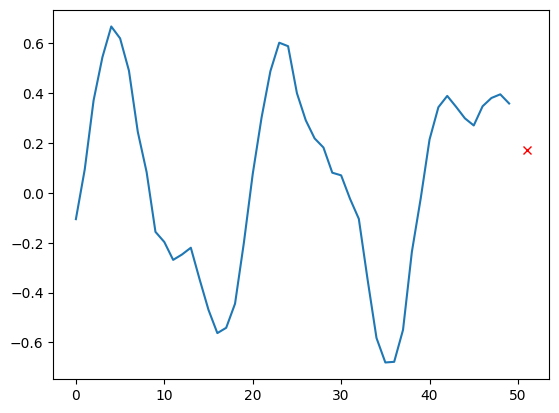

In [343]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [344]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [345]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [346]:
model_linear.summary()

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [347]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0866 - mean_squared_error: 0.0866 - val_loss: 0.0322 - val_mean_squared_error: 0.0322
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0198 - mean_squared_error: 0.0198 - val_loss: 0.0128 - val_mean_squared_error: 0.0128
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0113 - mean_squared_error: 0.0113 - val_loss: 0.0096 - val_mean_squared_error: 0.0096
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0092 - mean_squared_error: 0.0092 - val_loss: 0.0081 - val_mean_squared_error: 0.0081
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0080 - mean_squared_error: 0.0080 - val_loss: 0.0072 - val_mean_squared_error: 0.0072


In [348]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

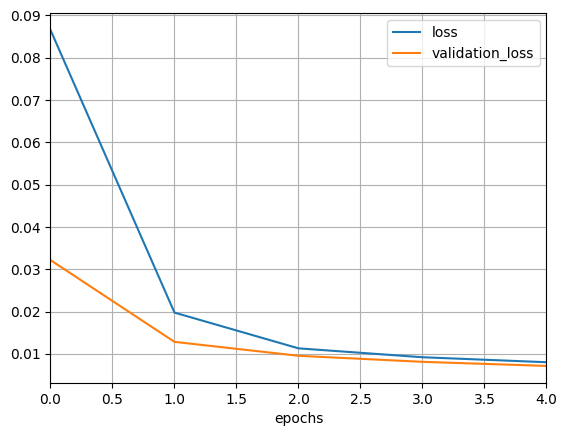

In [349]:
plot_function(history_linear)

In [350]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.007157684303820133
Test MSE:  0.007157684303820133


### 1.5 Simple RNN Model

In [351]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [352]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [353]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2734 - mean_squared_error: 0.2734 - val_loss: 0.2123 - val_mean_squared_error: 0.2123
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1472 - mean_squared_error: 0.1472 - val_loss: 0.1001 - val_mean_squared_error: 0.1001
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0697 - mean_squared_error: 0.0697 - val_loss: 0.0527 - val_mean_squared_error: 0.0527
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0453 - mean_squared_error: 0.0453 - val_loss: 0.0409 - val_mean_squared_error: 0.0409
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0386 - mean_squared_error: 0.0386 - val_loss: 0.0364 - val_mean_squared_error: 0.0364


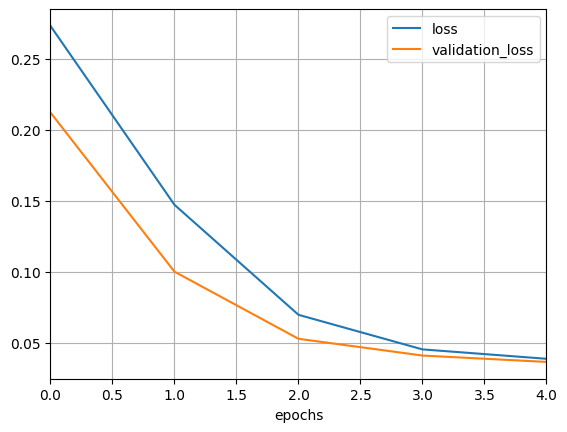

In [354]:
plot_function(history_simple_rnn)

In [355]:
score = model_simple_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.03388449177145958
Test MSE:  0.03388449177145958


### 1.5 Deep RNN Model

In [356]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [357]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [358]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0242 - mean_squared_error: 0.0242 - val_loss: 0.0101 - val_mean_squared_error: 0.0101
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0086 - mean_squared_error: 0.0086 - val_loss: 0.0064 - val_mean_squared_error: 0.0064
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0052 - val_mean_squared_error: 0.0052
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0051 - mean_squared_error: 0.0051 - val_loss: 0.0046 - val_mean_squared_error: 0.0046
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0040 - val_mean_squared_error: 0.0040


In [359]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.004505330231040716
Test MSE:  0.004505330231040716


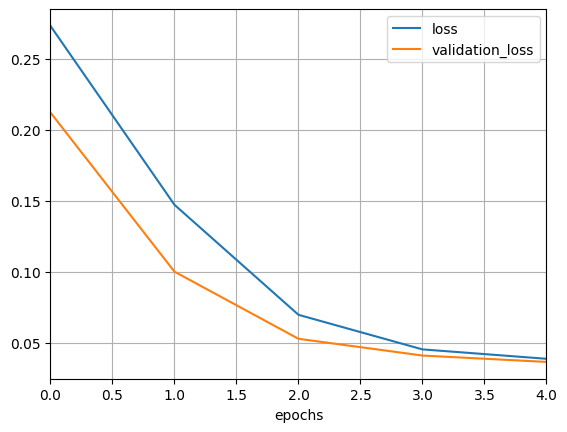

In [360]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [361]:
import keras
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from keras.optimizers import Adam

### 2.1 - Load dataset

In [362]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

### 2.2 - Dataset examination

In [363]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [364]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [365]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [366]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [367]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [368]:
optimizer = Adam(learning_rate = 0.001)

In [369]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [370]:
history_rnn = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.4994 - loss: 0.7014 - val_accuracy: 0.4934 - val_loss: 0.6953
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4999 - loss: 0.7018 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4988 - loss: 0.6957 - val_accuracy: 0.4938 - val_loss: 0.6944
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5003 - loss: 0.6960 - val_accuracy: 0.5062 - val_loss: 0.6934
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5003 - loss: 0.6957 - val_accuracy: 0.4938 - val_loss: 0.6943


In [371]:
rnn = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', rnn[0])
print(f'Test accuracy: ', rnn[1]*100, "%")

Test loss: 0.6938117742538452
Test accuracy:  50.0 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

# LSTM

In [372]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

In [373]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [374]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [375]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [376]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


In [377]:
optimizer = Adam(learning_rate = 0.001)
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history_lstm = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5156 - loss: 0.6944 - val_accuracy: 0.5062 - val_loss: 0.7017
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5569 - loss: 0.6834 - val_accuracy: 0.5150 - val_loss: 0.6919
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7341 - loss: 0.5182 - val_accuracy: 0.8094 - val_loss: 0.4173
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8210 - loss: 0.3965 - val_accuracy: 0.8168 - val_loss: 0.3999
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8397 - loss: 0.3668 - val_accuracy: 0.8264 - val_loss: 0.3973


In [378]:
lstm = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', lstm[0])
print(f'Test accuracy: ', lstm[1]*100, "%")

Test loss: 0.3835657835006714
Test accuracy:  82.95999765396118 %


# GRU

In [379]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

In [380]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [381]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [382]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [383]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


In [384]:
optimizer = Adam(learning_rate = 0.001)
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history_gru = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5962 - loss: 0.6348 - val_accuracy: 0.7614 - val_loss: 0.4985
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8105 - loss: 0.4155 - val_accuracy: 0.8262 - val_loss: 0.3900
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8429 - loss: 0.3562 - val_accuracy: 0.8378 - val_loss: 0.3759
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8590 - loss: 0.3237 - val_accuracy: 0.8338 - val_loss: 0.3791
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8687 - loss: 0.3047 - val_accuracy: 0.8258 - val_loss: 0.3805


In [385]:
gru = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', gru[0])
print(f'Test accuracy: ', gru[1]*100, "%")

Test loss: 0.3719528019428253
Test accuracy:  83.12000036239624 %


In [386]:
print("RNN:", rnn[1]*100, "%")
print("LSTM:", lstm[1]*100, "%")
print("GRU:", gru[1]*100, "%")

RNN: 50.0 %
LSTM: 82.95999765396118 %
GRU: 83.12000036239624 %


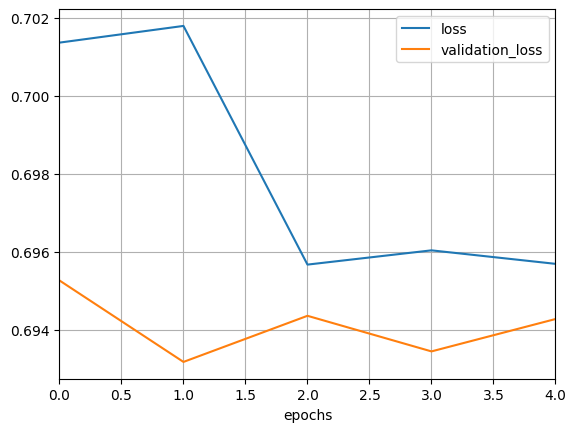

In [387]:
plot_function(history_rnn)

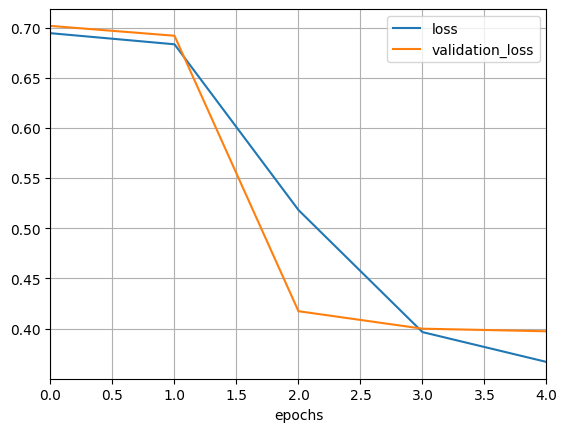

In [388]:
plot_function(history_lstm)

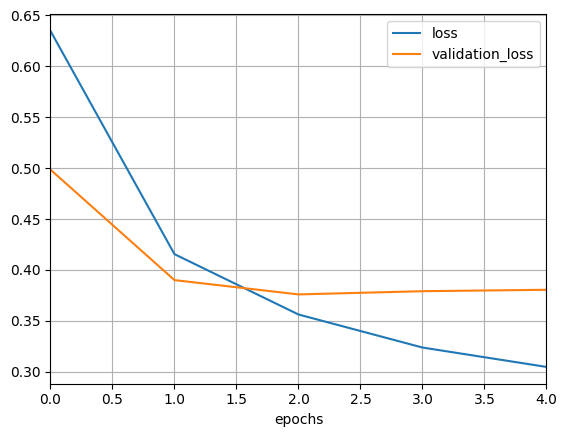

In [389]:
plot_function(history_gru)